# Preprocess SSP Population and GDP Inputs

Resamples SSP population and GDP files from their native high resolution (~0.008°, ~1 km) to 0.10° and applies log1p z-score normalization, matching the preprocessing used for the training data (`fix_data_pop_gdp.ipynb`).

Run this once before `projections.ipynb`. Output goes to `READY_data/inputs_normalized/ssp/`.

## 0. Input variable QA

Compares training inputs vs SSP inputs: raw value ranges, units, log1p distributions, and z-score compatibility.
Run this before preprocessing to catch unit mismatches between training and SSP datasets.

Variable Dataset                       Min              Max         Mean   log1p_mean    log1p_std
----------------------------------------------------------------------------------------------------
GDP      Train 2019/2020             0.000          101.493        3.107       0.8071       0.9013
GDP      SSP1 GDP 2030               0.000  11100998656.000   694004.312       2.4989       4.5071
  GDP log1p mean diff = 1.6918 -> per-file norm will handle unit difference

POP      Train 2019/2020             0.000      3436316.250     7608.233       6.6565       2.5805
POP      SSP1 POP 2030               0.000        30528.986       61.189       1.3892       1.9162
  POP log1p mean diff = 5.2674 -> per-file norm will handle unit difference



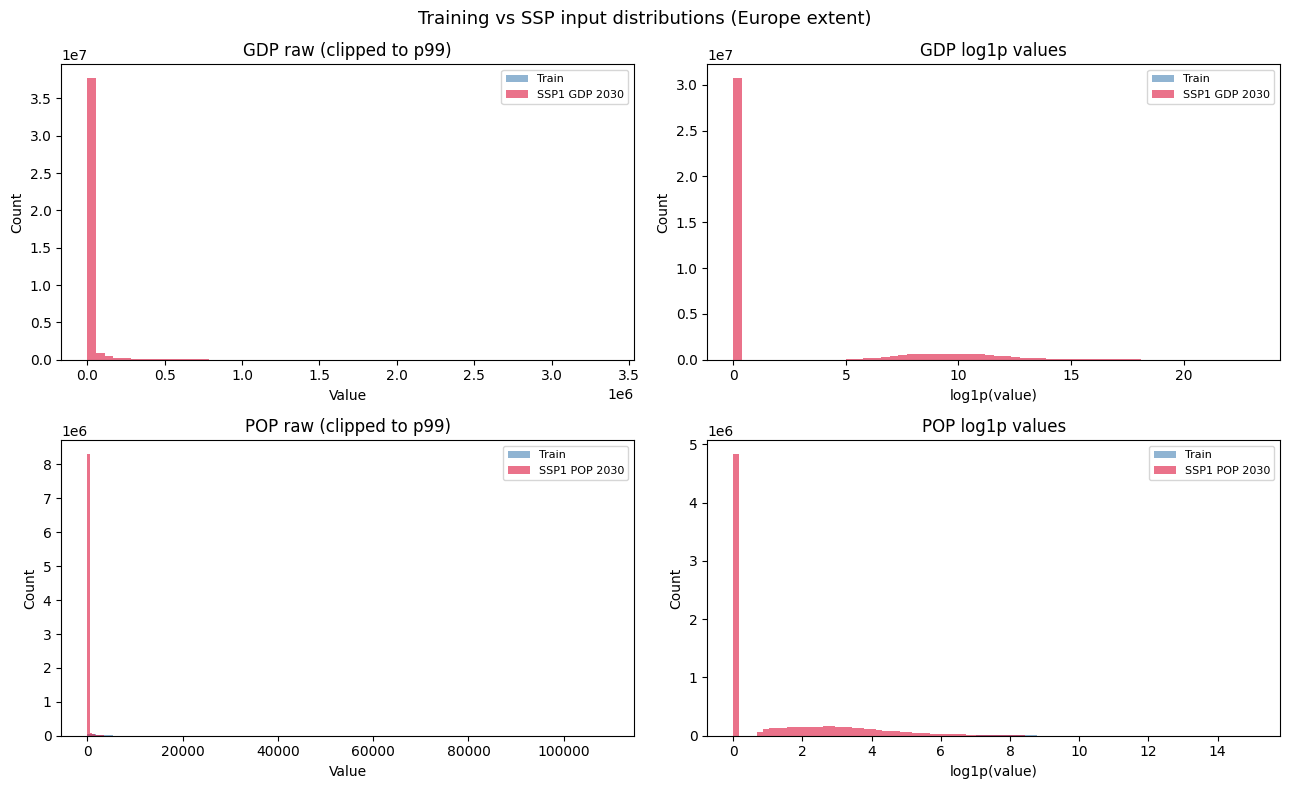

Saved qa_input_distributions.png


In [1]:
import numpy as np
import rasterio
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt

# Europe bounding box (matches training data extent)
EU_BOUNDS = (-25.5, 32.0, 45.5, 72.0)  # (left, bottom, right, top)

def load_clean(path):
    """Load raster clipped to Europe, mask nodata sentinels, return valid values.
    Clips to EU_BOUNDS to avoid loading full global files into memory."""
    with rasterio.open(path) as src:
        win = from_bounds(*EU_BOUNDS, transform=src.transform)
        win = win.crop(src.height, src.width)
        d = src.read(1, window=win).astype(np.float32)
        nodata = src.nodata
    if nodata is not None:
        d[d == nodata] = np.nan
    for flag in [-3.4028235e+38, -3.402823e+38, -99999, -9999, -32768]:
        d[np.isclose(d, flag, rtol=1e-5)] = np.nan
    d[d < -1e10] = np.nan
    d[np.isinf(d)] = np.nan
    d[d < 0] = np.nan
    return d[~np.isnan(d)]

INPUTS = {
    'GDP': {
        'train':     'READY_data/inputs/2019_gdp_aligned_010.tif',
        'ssp_ex':    r'READY_data/GDP SSP/GDP2030_ssp1.tif',
        'ssp_label': 'SSP1 GDP 2030',
    },
    'POP': {
        'train':     'READY_data/inputs/2020_pop_aligned_010.tif',
        'ssp_ex':    r'READY_data/SSP1/SSP1_2030_EU_UK_POP_01.tif',
        'ssp_label': 'SSP1 POP 2030',
    },
}

print(f"{'Variable':<8} {'Dataset':<20} {'Min':>12} {'Max':>16} {'Mean':>12} {'log1p_mean':>12} {'log1p_std':>12}")
print('-' * 100)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Training vs SSP input distributions (Europe extent)', fontsize=13)

for row, (var, paths) in enumerate(INPUTS.items()):
    train_vals = load_clean(paths['train'])
    ssp_vals   = load_clean(paths['ssp_ex'])

    for label, vals in [('Train 2019/2020', train_vals), (paths['ssp_label'], ssp_vals)]:
        lv = np.log1p(vals)
        print(f"{var:<8} {label:<20} {vals.min():>12.3f} {vals.max():>16.3f} {vals.mean():>12.3f} {lv.mean():>12.4f} {lv.std():>12.4f}")

    log_mean_diff = abs(np.log1p(train_vals).mean() - np.log1p(ssp_vals).mean())
    status = 'per-file norm will handle unit difference' if log_mean_diff >= 0.5 else 'similar scale'
    print(f'  {var} log1p mean diff = {log_mean_diff:.4f} -> {status}')
    print()

    ax = axes[row, 0]
    p99 = max(np.percentile(train_vals, 99), np.percentile(ssp_vals, 99))
    ax.hist(train_vals[train_vals <= p99], bins=60, alpha=0.6, color='steelblue', label='Train')
    ax.hist(ssp_vals[ssp_vals <= p99],     bins=60, alpha=0.6, color='crimson',   label=paths['ssp_label'])
    ax.set_title(f'{var} raw (clipped to p99)')
    ax.set_xlabel('Value'); ax.set_ylabel('Count'); ax.legend(fontsize=8)

    ax = axes[row, 1]
    ax.hist(np.log1p(train_vals), bins=60, alpha=0.6, color='steelblue', label='Train')
    ax.hist(np.log1p(ssp_vals),   bins=60, alpha=0.6, color='crimson',   label=paths['ssp_label'])
    ax.set_title(f'{var} log1p values')
    ax.set_xlabel('log1p(value)'); ax.set_ylabel('Count'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/qa_input_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved qa_input_distributions.png')


## 1. Setup load reference grid

Loads the CISI label raster to extract the target 0.10° grid (extent, CRS, affine transform). All SSP inputs will be reprojected onto this exact grid so every pixel aligns with the training labels.

In [2]:
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject

OUTPUT_DIR   = r'READY_data\inputs_normalized\ssp'
REFERENCE    = r'READY_data\labels\2024_CISI_010deg_nearest.tif'  # defines the 0.10° grid
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load reference grid
with rasterio.open(REFERENCE) as ref:
    ref_crs       = ref.crs
    ref_transform = ref.transform
    ref_height    = ref.height
    ref_width     = ref.width
    ref_profile   = ref.profile.copy()

print(f'Reference grid: {ref_height}x{ref_width}, res={ref_transform[0]:.3f}°')

Reference grid: 485x570, res=0.100°


## 2. Resample and normalize function

Defines the core processing function applied to every input file:
1. **Reproject** to 0.10 degree grid — average resampling for GDP (density field), sum for POP (extensive quantity)
2. **Clean nodata** — removes sentinel values (-3.4e38, -99999, etc.)
3. **Per-file log1p z-score normalization** — matches the method used in fix_data_pop_gdp.ipynb for training data. Each file is normalized by its own log1p mean/std, ensuring the model sees the same distribution regardless of absolute unit differences between datasets.

In [3]:
# Resampling methods
# GDP: average (aggregates ~121 source pixels per 0.1deg cell, correct for density field)
# POP: sum (extensive quantity - preserves total persons per cell)
RESAMPLE_METHOD = {
    'gdp': Resampling.average,
    'pop': Resampling.sum,
}

def resample_and_normalize(input_path, output_path, kind):
    """Resample to 0.10 degree grid then apply per-file log1p z-score normalization.
    
    Uses per-file normalization (same as fix_data_pop_gdp.ipynb used for training data),
    ensuring the model sees the same z-score distribution at inference as during training.
    Absolute scale differences between GDP datasets (Chen & Gao vs Wang & Sun) are
    irrelevant because both are normalized to mean=0, std=1 per file.
    """
    print(f'Processing: {os.path.basename(input_path)}')

    # Step 1: Resample to reference grid
    data = np.full((ref_height, ref_width), np.nan, dtype=np.float32)
    with rasterio.open(input_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=data,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=RESAMPLE_METHOD[kind],
        )

    # Step 2: Clean nodata flags
    for flag in [-3.4028235e+38, -3.402823e+38, -99999, -9999, -32768]:
        data[np.isclose(data, flag, rtol=1e-5)] = np.nan
    data[data < -1e10] = np.nan
    data[np.isinf(data)] = np.nan
    data[data < 0] = np.nan  # no negative GDP or population

    valid = ~np.isnan(data)
    print(f'  Valid pixels after resample: {valid.sum():,}')

    if valid.sum() == 0:
        print('  WARNING: No valid data after cleaning!')
        return

    # Step 3: Per-file log1p z-score normalization (matches fix_data_pop_gdp.ipynb)
    log_vals = np.log1p(data[valid])
    mean_val = log_vals.mean()
    std_val  = log_vals.std()

    normalized = np.full_like(data, np.nan)
    normalized[valid] = (np.log1p(data[valid]) - mean_val) / (std_val + 1e-8)

    print(f'  log1p mean={mean_val:.4f}, std={std_val:.4f}')
    print(f'  Normalized range: [{np.nanmin(normalized):.3f}, {np.nanmax(normalized):.3f}]  mean={np.nanmean(normalized):.4f}')

    # Step 4: Save
    profile = ref_profile.copy()
    profile.update(dtype='float32', count=1, nodata=np.nan)
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(normalized[np.newaxis, :, :])
    print(f'  Saved -> {output_path}')


## 3. Process population files (15 files)

Runs the resample+normalize function on all 15 SSP population rasters (SSP1â€“5 Ã— 2030/2050/2100). Source files are at ~0.008° (~1 km). Output: `POP_SSP{n}_{year}_normalized.tif`. Skips files that already exist.

In [4]:
# All 15 SSP population files
POP_FILES = {
    'SSP1': {
        2030: r'READY_data\SSP1\SSP1_2030_EU_UK_POP_01.tif',
        2050: r'READY_data\SSP1\SSP1_2050_EU_UK_POP_01.tif',
        2100: r'READY_data\SSP1\SSP1_2100_EU_UK_POP_01.tif',
    },
    'SSP2': {
        2030: r'READY_data\SSP2\SSP2_2030_EU_UK_POP_01.tif',
        2050: r'READY_data\SSP2\SSP2_2050_EU_UK_POP_01.tif',
        2100: r'READY_data\SSP2\SSP2_2100_EU_UK_POP_01.tif',
    },
    'SSP3': {
        2030: r'READY_data\SSP3\SSP3_2030_EU_UK_POP_01.tif',
        2050: r'READY_data\SSP3\SSP3_2050_EU_UK_POP_01.tif',
        2100: r'READY_data\SSP3\SSP3_2100_EU_UK_POP_01.tif',
    },
    'SSP4': {
        2030: r'READY_data\SSP4\SSP4_2030_EU_UK_POP_01.tif',
        2050: r'READY_data\SSP4\SSP4_2050_EU_UK_POP_01.tif',
        2100: r'READY_data\SSP4\SSP4_2100_EU_UK_POP_01.tif',
    },
    'SSP5': {
        2030: r'READY_data\SSP5\SSP5_2030_EU_UK_POP_01.tif',
        2050: r'READY_data\SSP5\SSP5_2050_EU_UK_POP_01.tif',
        2100: r'READY_data\SSP5\SSP5_2100_EU_UK_POP_01.tif',
    },
}

for ssp, years in POP_FILES.items():
    for year, in_path in years.items():
        out_path = os.path.join(OUTPUT_DIR, f'POP_{ssp}_{year}_normalized.tif')
        if os.path.exists(out_path):
            print(f'Skipping {ssp} {year} pop (already exists)')
            continue
        resample_and_normalize(in_path, out_path, kind='pop')

print('\nAll population files processed.')

Processing: SSP1_2030_EU_UK_POP_01.tif
  Valid pixels after resample: 63,811
  log1p mean=6.6047, std=3.0040
  Normalized range: [-2.199, 2.644]  mean=0.0000
  Saved -> READY_data\inputs_normalized\ssp\POP_SSP1_2030_normalized.tif
Processing: SSP1_2050_EU_UK_POP_01.tif
  Valid pixels after resample: 63,811
  log1p mean=6.4939, std=3.1136
  Normalized range: [-2.086, 2.605]  mean=-0.0000
  Saved -> READY_data\inputs_normalized\ssp\POP_SSP1_2050_normalized.tif
Processing: SSP1_2100_EU_UK_POP_01.tif
  Valid pixels after resample: 63,811
  log1p mean=6.1260, std=3.3034
  Normalized range: [-1.854, 2.570]  mean=0.0000
  Saved -> READY_data\inputs_normalized\ssp\POP_SSP1_2100_normalized.tif
Processing: SSP2_2030_EU_UK_POP_01.tif
  Valid pixels after resample: 63,811
  log1p mean=6.5989, std=3.0091
  Normalized range: [-2.193, 2.641]  mean=-0.0000
  Saved -> READY_data\inputs_normalized\ssp\POP_SSP2_2030_normalized.tif
Processing: SSP2_2050_EU_UK_POP_01.tif
  Valid pixels after resample: 63,8

## 4. Resolution check â€” verify all outputs

Checks the resolution of raw inputs vs. normalized outputs. Confirms all 30 output files exist and are at 0.10°. Run this after processing to verify everything is correct before running `projections.ipynb`.

In [5]:
_NORM_DIR = r'READY_data\inputs_normalized\ssp'
_SSPS  = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']
_YEARS = [2030, 2050, 2100]

# --- Raw input resolution check ---
print('=== RAW INPUT RESOLUTIONS ===')
raw_files = {
    'CISI label (target)':     r'READY_data\labels\2024_CISI_010deg_nearest.tif',
    'GDP training (2019)':     r'READY_data\inputs\2019_gdp_aligned_010.tif',
    'Pop training (2020)':     r'READY_data\inputs\2020_pop_aligned_010.tif',
    'Land cover (2020)':       r'READY_data\landuse_onehot\clipped_history_2020_onehot.tif',
    'GDP SSP raw (SSP1 2030)': r'READY_data\GDP SSP\GDP2030_ssp1.tif',
    'Pop SSP raw (SSP1 2030)': r'READY_data\SSP1\SSP1_2030_EU_UK_POP_01.tif',
}
print(f'  {"File":<35} {"Shape":>12} {"Res (°)":>10}  {"0.1° match?"}')
print('  ' + '-' * 75)
for label, path in raw_files.items():
    if not os.path.exists(path):
        print(f'  {label:<35} FILE NOT FOUND')
        continue
    with rasterio.open(path) as src:
        res_x = abs(src.transform[0])
        shape = f'{src.height}x{src.width}'
    ok = 'âœ“' if abs(res_x - 0.1) < 0.001 else f'âœ—  ({res_x:.5f}° â€” will be resampled)'
    print(f'  {label:<35} {shape:>12} {res_x:>10.5f}  {ok}')

# --- All 30 normalized output files ---
print('\n=== NORMALIZED OUTPUT FILES (all 30) ===')
print(f'  {"File":<40} {"Shape":>12} {"Res (°)":>10}  {"Status"}')
print('  ' + '-' * 80)

all_ok = True
for ssp in _SSPS:
    for year in _YEARS:
        for kind in ['POP', 'GDP']:
            fname = f'{kind}_{ssp}_{year}_normalized.tif'
            path  = os.path.join(_NORM_DIR, fname)
            if not os.path.exists(path):
                print(f'  {fname:<40} MISSING')
                all_ok = False
                continue
            with rasterio.open(path) as src:
                res_x = abs(src.transform[0])
                shape = f'{src.height}x{src.width}'
            ok = 'âœ“' if abs(res_x - 0.1) < 0.001 else f'âœ—  wrong res: {res_x:.5f}°'
            print(f'  {fname:<40} {shape:>12} {res_x:>10.5f}  {ok}')
            if abs(res_x - 0.1) >= 0.001:
                all_ok = False

print()
print('All 30 files present and at 0.1°.' if all_ok else 'WARNING: some files are missing or at wrong resolution.')

=== RAW INPUT RESOLUTIONS ===
  File                                       Shape    Res (°)  0.1° match?
  ---------------------------------------------------------------------------
  CISI label (target)                      485x570    0.10000  âœ“
  GDP training (2019)                      485x570    0.10000  âœ“
  Pop training (2020)                      485x570    0.10000  âœ“
  Land cover (2020)                        485x570    0.10000  âœ“
  GDP SSP raw (SSP1 2030)              18000x43200    0.00833  âœ—  (0.00833° â€” will be resampled)
  Pop SSP raw (SSP1 2030)                4554x8480    0.00833  âœ—  (0.00833° â€” will be resampled)

=== NORMALIZED OUTPUT FILES (all 30) ===
  File                                            Shape    Res (°)  Status
  --------------------------------------------------------------------------------
  POP_SSP1_2030_normalized.tif                  485x570    0.10000  âœ“
  GDP_SSP1_2030_normalized.tif             MISSING
  POP_SSP1_2050_normaliz

## 5. Process GDP files (15 files)

Same as step 3 but for GDP. Source files are in `READY_data/GDP SSP/` at ~0.008° resolution. Output: `GDP_SSP{n}_{year}_normalized.tif`. Skips files that already exist.

In [6]:
GDP_FILES = {
    'SSP1': {
        2030: r'READY_data\GDP SSP\GDP2030_ssp1.tif',
        2050: r'READY_data\GDP SSP\GDP2050_ssp1.tif',
        2100: r'READY_data\GDP SSP\GDP2100_ssp1.tif',
    },
    'SSP2': {
        2030: r'READY_data\GDP SSP\GDP2030_ssp2.tif',
        2050: r'READY_data\GDP SSP\GDP2050_ssp2.tif',
        2100: r'READY_data\GDP SSP\GDP2100_ssp2.tif',
    },
    'SSP3': {
        2030: r'READY_data\GDP SSP\GDP2030_ssp3.tif',
        2050: r'READY_data\GDP SSP\GDP2050_ssp3.tif',
        2100: r'READY_data\GDP SSP\GDP2100_ssp3.tif',
    },
    'SSP4': {
        2030: r'READY_data\GDP SSP\GDP2030_ssp4.tif',
        2050: r'READY_data\GDP SSP\GDP2050_ssp4.tif',
        2100: r'READY_data\GDP SSP\GDP2100_ssp4.tif',
    },
    'SSP5': {
        2030: r'READY_data\GDP SSP\GDP2030_ssp5.tif',
        2050: r'READY_data\GDP SSP\GDP2050_ssp5.tif',
        2100: r'READY_data\GDP SSP\GDP2100_ssp5.tif',
    },
}

for ssp, years in GDP_FILES.items():
    for year, in_path in years.items():
        out_path = os.path.join(OUTPUT_DIR, f'GDP_{ssp}_{year}_normalized.tif')
        if os.path.exists(out_path):
            print(f'Skipping {ssp} {year} GDP (already exists)')
            continue
        resample_and_normalize(in_path, out_path, kind='gdp')

print('\nAll GDP files processed.')

Processing: GDP2030_ssp1.tif
  Valid pixels after resample: 276,450
  log1p mean=3.3397, std=5.1726
  Normalized range: [-0.646, 3.413]  mean=0.0000
  Saved -> READY_data\inputs_normalized\ssp\GDP_SSP1_2030_normalized.tif
Processing: GDP2050_ssp1.tif
  Valid pixels after resample: 276,450
  log1p mean=3.4365, std=5.3152
  Normalized range: [-0.647, 3.384]  mean=-0.0000
  Saved -> READY_data\inputs_normalized\ssp\GDP_SSP1_2050_normalized.tif
Processing: GDP2100_ssp1.tif
  Valid pixels after resample: 276,450
  log1p mean=3.5426, std=5.4760
  Normalized range: [-0.647, 3.388]  mean=-0.0000
  Saved -> READY_data\inputs_normalized\ssp\GDP_SSP1_2100_normalized.tif
Processing: GDP2030_ssp2.tif
  Valid pixels after resample: 276,450
  log1p mean=3.3442, std=5.1767
  Normalized range: [-0.646, 3.404]  mean=-0.0000
  Saved -> READY_data\inputs_normalized\ssp\GDP_SSP2_2030_normalized.tif
Processing: GDP2050_ssp2.tif
  Valid pixels after resample: 276,450
  log1p mean=3.4293, std=5.3003
  Normali

## 5b. GDP — Wang & Sun 2022 SSP files

Once you have downloaded the Wang & Sun 2022 SSP GDP files from https://doi.org/10.5281/zenodo.5880037,
place them in `READY_data/GDP SSP WangSun/` and run this cell.

The files are in Mollweide (ESRI:54009) at 1km — same format as the 2019 training file.
Processing: reproject Mollweide -> EPSG:4326, clip to Europe, bilinear resample to 0.10 degrees.

In [7]:
import os
from rasterio.warp import reproject, Resampling
import rasterio
import numpy as np

# Expected folder once you download from https://doi.org/10.5281/zenodo.5880037
WANGSUN_DIR = r'READY_data/GDP SSP WangSun'

# Wang & Sun file naming convention (adjust if different after download)
# Expected: GDP_SSP1_2030.tif, GDP_SSP1_2050.tif, etc. in Mollweide 1km
WANGSUN_FILES = {
    'SSP1': {2030: 'GDP_SSP1_2030.tif', 2050: 'GDP_SSP1_2050.tif', 2100: 'GDP_SSP1_2100.tif'},
    'SSP2': {2030: 'GDP_SSP2_2030.tif', 2050: 'GDP_SSP2_2050.tif', 2100: 'GDP_SSP2_2100.tif'},
    'SSP3': {2030: 'GDP_SSP3_2030.tif', 2050: 'GDP_SSP3_2050.tif', 2100: 'GDP_SSP3_2100.tif'},
    'SSP4': {2030: 'GDP_SSP4_2030.tif', 2050: 'GDP_SSP4_2050.tif', 2100: 'GDP_SSP4_2100.tif'},
    'SSP5': {2030: 'GDP_SSP5_2030.tif', 2050: 'GDP_SSP5_2050.tif', 2100: 'GDP_SSP5_2100.tif'},
}

if not os.path.exists(WANGSUN_DIR):
    print(f'ERROR: {WANGSUN_DIR} not found. Download from https://doi.org/10.5281/zenodo.5880037 first.')
else:
    for ssp, years in WANGSUN_FILES.items():
        for year, fname in years.items():
            in_path  = os.path.join(WANGSUN_DIR, fname)
            out_path = os.path.join(OUTPUT_DIR, f'GDP_{ssp}_{year}_normalized.tif')
            if os.path.exists(out_path):
                print(f'Skipping {ssp} {year} GDP (already exists)')
                continue
            if not os.path.exists(in_path):
                print(f'MISSING: {in_path}')
                continue
            resample_and_normalize(in_path, out_path, kind='gdp')
    print('All Wang & Sun GDP files processed.')


ERROR: READY_data/GDP SSP WangSun not found. Download from https://doi.org/10.5281/zenodo.5880037 first.


## 6. Verify GDP outputs

In [8]:
_NORM_DIR = r'READY_data\inputs_normalized\ssp'
_SSPS  = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']
_YEARS = [2030, 2050, 2100]

print(f'{"File":<35} {"Shape":>12} {"Valid px":>10} {"Min":>8} {"Max":>8} {"Mean":>8}  {"OK?"}')
print('-' * 100)

all_ok = True
for ssp in _SSPS:
    for year in _YEARS:
        fname = f'GDP_{ssp}_{year}_normalized.tif'
        path  = os.path.join(_NORM_DIR, fname)
        if not os.path.exists(path):
            print(f'{fname:<35} MISSING')
            all_ok = False
            continue
        with rasterio.open(path) as src:
            data  = src.read(1).astype(np.float32)
            res_x = abs(src.transform[0])
            shape = f'{src.height}x{src.width}'
        valid = ~np.isnan(data)
        res_ok    = abs(res_x - 0.1) < 0.001
        has_data  = valid.sum() > 0
        no_extremes = np.all(np.abs(data[valid]) < 20) if has_data else False
        ok = '✓' if (res_ok and has_data and no_extremes) else '✗'
        if not (res_ok and has_data and no_extremes):
            all_ok = False
        print(f'{fname:<35} {shape:>12} {valid.sum():>10,} {np.nanmin(data):>8.3f} {np.nanmax(data):>8.3f} {np.nanmean(data):>8.4f}  {ok}')

print()
print('All GDP files OK.' if all_ok else 'WARNING: one or more GDP files have issues.')

File                                       Shape   Valid px      Min      Max     Mean  OK?
----------------------------------------------------------------------------------------------------
GDP_SSP1_2030_normalized.tif             485x570    276,450   -0.646    3.413   0.0000  ✓
GDP_SSP1_2050_normalized.tif             485x570    276,450   -0.647    3.384  -0.0000  ✓
GDP_SSP1_2100_normalized.tif             485x570    276,450   -0.647    3.388  -0.0000  ✓
GDP_SSP2_2030_normalized.tif             485x570    276,450   -0.646    3.404  -0.0000  ✓
GDP_SSP2_2050_normalized.tif             485x570    276,450   -0.647    3.375   0.0000  ✓
GDP_SSP2_2100_normalized.tif             485x570    276,450   -0.649    3.333   0.0000  ✓
GDP_SSP3_2030_normalized.tif             485x570    276,450   -0.646    3.399   0.0000  ✓
GDP_SSP3_2050_normalized.tif             485x570    276,450   -0.646    3.389  -0.0000  ✓
GDP_SSP3_2100_normalized.tif             485x570    276,450   -0.646    3.420   0.0000 

## 7. Process land cover files (15 scenarios x 7 classes = 105 files)

Reprojects global 1km LC rasters from EPSG:6933 to EPSG:4326, clips to the Europe 0.10° reference grid (-25 to 32° lon, 32.41 to 80.91° lat), one-hot encodes 7 classes, and saves one file per class per scenario.

Source: `Global 7-land-types LULC projection dataset under SSPs-RCPs (1)/`
Output: `LC_SSP{n}_{year}_class_{c}.tif` in `READY_data/inputs_normalized/ssp/`

In [9]:
LC_BASE = r'Global 7-land-types LULC projection dataset under SSPs-RCPs'

LC_FILES = {
    'SSP1': {'rcp': 'RCP26', 'years': {2030: 'global_SSP1_RCP26_2030.tif', 2050: 'global_SSP1_RCP26_2050.tif', 2100: 'global_SSP1_RCP26_2100.tif'}},
    'SSP2': {'rcp': 'RCP45', 'years': {2030: 'global_SSP2_RCP45_2030.tif', 2050: 'global_SSP2_RCP45_2050.tif', 2100: 'global_SSP2_RCP45_2100.tif'}},
    'SSP3': {'rcp': 'RCP70', 'years': {2030: 'global_SSP3_RCP70_2030.tif', 2050: 'global_SSP3_RCP70_2050.tif', 2100: 'global_SSP3_RCP70_2100.tif'}},
    'SSP4': {'rcp': 'RCP60', 'years': {2030: 'global_SSP4_RCP60_2030.tif', 2050: 'global_SSP4_RCP60_2050.tif', 2100: 'global_SSP4_RCP60_2100.tif'}},
    'SSP5': {'rcp': 'RCP85', 'years': {2030: 'global_SSP5_RCP85_2030.tif', 2050: 'global_SSP5_RCP85_2050.tif', 2100: 'global_SSP5_RCP85_2100.tif'}},
}

from rasterio.warp import calculate_default_transform, reproject as rio_reproject
from rasterio.enums import Resampling as RioResampling

def process_lc(in_path, out_dir, ssp, year):
    """Reproject, clip to Europe, one-hot encode, save 7 class files."""
    print(f'Processing LC: {os.path.basename(in_path)}')

    # Step 1: reproject to EPSG:4326 at 0.10 deg, clipped to Europe
    dst_crs = ref_crs
    dst_transform = ref_transform
    dst_h, dst_w = ref_height, ref_width

    data = np.zeros((dst_h, dst_w), dtype=np.uint8)

    with rasterio.open(in_path) as src:
        rio_reproject(
            source=rasterio.band(src, 1),
            destination=data,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=RioResampling.nearest,  # categorical data — nearest neighbour
        )

    # Step 2: one-hot encode — save one file per class (1–7)
    profile = ref_profile.copy()
    profile.update(dtype='float32', count=1, nodata=np.nan)

    for c in range(1, 8):
        out_path = os.path.join(out_dir, f'LC_{ssp}_{year}_class_{c}.tif')
        if os.path.exists(out_path):
            print(f'  Skipping class {c} (already exists)')
            continue
        class_mask = (data == c).astype(np.float32)
        # set pixels where data==0 (nodata/ocean) to NaN
        class_mask[data == 0] = np.nan
        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(class_mask[np.newaxis, :, :])
        print(f'  Saved class {c} -> {out_path}')


for ssp, info in LC_FILES.items():
    rcp = info['rcp']
    folder = os.path.join(LC_BASE, f'{ssp}_{rcp}')
    for year, fname in info['years'].items():
        in_path = os.path.join(folder, fname)
        if not os.path.exists(in_path):
            print(f'MISSING: {in_path}')
            continue
        # skip if all 7 classes already done
        already = all(os.path.exists(os.path.join(OUTPUT_DIR, f'LC_{ssp}_{year}_class_{c}.tif')) for c in range(1,8))
        if already:
            print(f'Skipping {ssp} {year} LC (all 7 classes exist)')
            continue
        process_lc(in_path, OUTPUT_DIR, ssp, year)

print('All LC files processed.')

Skipping SSP1 2030 LC (all 7 classes exist)
Skipping SSP1 2050 LC (all 7 classes exist)
Skipping SSP1 2100 LC (all 7 classes exist)
Skipping SSP2 2030 LC (all 7 classes exist)
Skipping SSP2 2050 LC (all 7 classes exist)
Skipping SSP2 2100 LC (all 7 classes exist)
Skipping SSP3 2030 LC (all 7 classes exist)
Skipping SSP3 2050 LC (all 7 classes exist)
Skipping SSP3 2100 LC (all 7 classes exist)
Skipping SSP4 2030 LC (all 7 classes exist)
Skipping SSP4 2050 LC (all 7 classes exist)
Skipping SSP4 2100 LC (all 7 classes exist)
Skipping SSP5 2030 LC (all 7 classes exist)
Skipping SSP5 2050 LC (all 7 classes exist)
Skipping SSP5 2100 LC (all 7 classes exist)
All LC files processed.
